The goal of this notebook is to analyse the articles from the British Journals of Pharmacology.

In [1]:
import json 
import pyalex as alex
alex.config.email = "gabriel.vignon@ensta.fr"
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import aquarel
from IPython.display import clear_output

# Source

## Extraction

Extracting the data: 

In [2]:
source = (
    alex.Sources()["s55107261"] # ID OpenAlex of the BJP
)

concurrence = ( 
    alex.Sources()
    .search("pharmacology OR pharmacological OR pharmaceutics OR pharmaceutical OR pharmacy OR drug OR drugs") # does not include some journals like Nature Reviews Drugs Discovery
    .get()
) # 1672 found
#concurrence.meta


In [3]:
pharma_reviews = (
    alex.Sources()
    .search("Pharmacological Reviews")
    .get()
)
pharma_reviews = pd.DataFrame(pharma_reviews)

Saving the data:

In [ ]:
# with open("data/sources/bjp.json", "w") as f:
#     json.dump(source, f, indent = 4)

# book = []

# # pages
# for i in range(1, 10):
#     book.append(concurrence.get(page = i, per_page = 200))

# # Save the pages
# for i in range(1, 10):
#     with open(f"data/sources/concurrence_{i}.json", "w") as f:
#         json.dump(book[i-1], f, indent = 4)

AttributeError: 'OpenAlexResponseList' object has no attribute 'get'

## Analysis - Counts by year 

### BJP only

In [29]:
source_counts_by_year = source["counts_by_year"]

In [30]:
with open("data/sources/bjp_counts_by_year.json", "w") as f:
    json.dump(source_counts_by_year, f, indent = 4)

In [31]:
df_source = pd.read_json("data/sources/bjp_counts_by_year.json")
df_source.set_index("year", inplace = True)
df_source.drop(index = 2025, inplace = True) # dropping the current year
df_source.head()

,works_count,oa_works_count,cited_by_count
year,,,
2024,343,181,41739
2023,313,194,45240
2022,265,218,47962
2021,462,421,51639
2020,431,390,48636


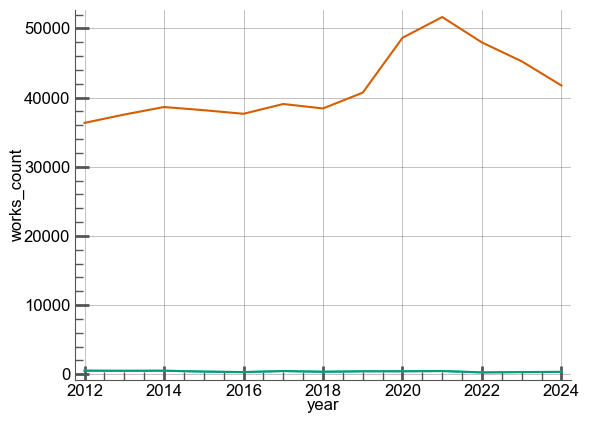

In [34]:
sns.lineplot(data = df_source, x = "year", y = "works_count")
plt.show()

In [33]:
sns.lineplot(data = df_source, x = "year", y = "cited_by_count")

<Axes: xlabel='year', ylabel='works_count'>

### BJP & co.

In [6]:
dfs_concurrence = []
for i in range(1, 10):
    with open(f"data/sources/concurrence_{i}.json", "r") as f:
        dfs_concurrence.append(pd.DataFrame.from_dict(json.load(f)))

df_concurrence = pd.concat(dfs_concurrence, ignore_index = True)
df_concurrence["impact"] = df_concurrence["cited_by_count"]/df_concurrence["works_count"]
df_concurrence = df_concurrence[df_concurrence["works_count"]>150]

In [36]:
top_20 = df_concurrence[["display_name", "impact", "cited_by_count", "host_organization", "works_count", "id"]].sort_values(by = "impact", ascending = False).reset_index()[:25]
# JIF = over the last 2 years
# Here: since the beginning  

#### Top journals

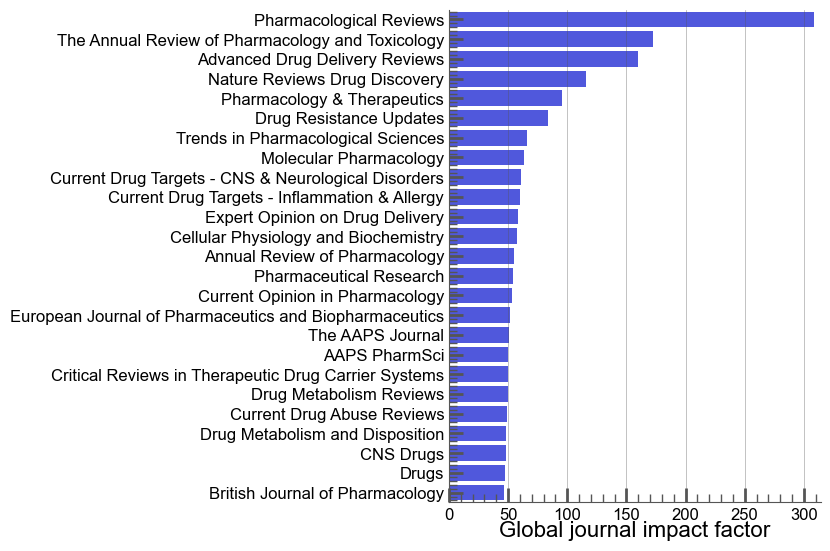

In [37]:
with aquarel.load_theme("scientific"):
    plt.figure(figsize=(4.8,6.4))
    sns.barplot(data = top_20, x = "impact", y = "display_name", orient = "h", color="#3944f3", legend = True)
    #plt.xticks(rotation = 90)
    plt.xlabel("Global journal impact factor", fontsize=16)
    plt.ylabel("")
    plt.show()

In [41]:
df_concurrence

,id,issn_l,issn,display_name,host_organization,host_organization_name,host_organization_lineage,relevance_score,works_count,cited_by_count,...,abbreviated_title,type,topics,topic_share,x_concepts,counts_by_year,works_api_url,updated_date,created_date,impact
0,https://openalex.org/S118304455,0022-3573,"[0022-3573, 2042-7158]",Journal of Pharmacy and Pharmacology,https://openalex.org/P4310311648,Oxford University Press,"[https://openalex.org/P4310311647, https://ope...",12873.200000,18389,376976,...,None,journal,"[{'id': 'https://openalex.org/T11178', 'displa...","[{'id': 'https://openalex.org/T10256', 'displa...","[{'id': 'https://openalex.org/C71924100', 'wik...","[{'year': 2025, 'works_count': 54, 'cited_by_c...",https://api.openalex.org/works?filter=primary_...,2025-07-24T01:22:33.969222,2016-06-24,20.500082
1,https://openalex.org/S131016564,0378-5173,"[0378-5173, 1873-3476]",International Journal of Pharmaceutics,https://openalex.org/P4310320990,Elsevier BV,[https://openalex.org/P4310320990],10054.593000,23804,1066459,...,None,journal,"[{'id': 'https://openalex.org/T10256', 'displa...","[{'id': 'https://openalex.org/T10256', 'displa...","[{'id': 'https://openalex.org/C185592680', 'wi...","[{'year': 2025, 'works_count': 739, 'cited_by_...",https://api.openalex.org/works?filter=primary_...,2025-07-24T18:55:17.700287,2016-06-24,44.801672
2,https://openalex.org/S186543748,1474-1776,"[1474-1776, 1474-1784]",Nature Reviews Drug Discovery,https://openalex.org/P4310319908,Nature Portfolio,"[https://openalex.org/P4310319908, https://ope...",9648.065000,6009,696211,...,None,journal,"[{'id': 'https://openalex.org/T13656', 'displa...","[{'id': 'https://openalex.org/T13656', 'displa...","[{'id': 'https://openalex.org/C86803240', 'wik...","[{'year': 2025, 'works_count': 149, 'cited_by_...",https://api.openalex.org/works?filter=primary_...,2025-07-22T17:35:49.069571,2016-06-24,115.861375
3,https://openalex.org/S185534594,0006-2952,"[0006-2952, 1873-2968]",Biochemical Pharmacology,https://openalex.org/P4310320990,Elsevier BV,[https://openalex.org/P4310320990],9636.810000,30861,1167925,...,None,journal,"[{'id': 'https://openalex.org/T10375', 'displa...","[{'id': 'https://openalex.org/T10375', 'displa...","[{'id': 'https://openalex.org/C86803240', 'wik...","[{'year': 2025, 'works_count': 376, 'cited_by_...",https://api.openalex.org/works?filter=primary_...,2025-07-21T16:20:50.721032,2016-06-24,37.844691
4,https://openalex.org/S159852663,0009-9236,"[0009-9236, 1085-8733, 1532-6535]",Clinical Pharmacology & Therapeutics,https://openalex.org/P4310320595,Wiley,[https://openalex.org/P4310320595],9547.538000,17176,628260,...,None,journal,"[{'id': 'https://openalex.org/T10375', 'displa...","[{'id': 'https://openalex.org/T10375', 'displa...","[{'id': 'https://openalex.org/C71924100', 'wik...","[{'year': 2025, 'works_count': 239, 'cited_by_...",https://api.openalex.org/works?filter=primary_...,2025-07-24T02:57:33.052838,2016-06-24,36.577783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1283,https://openalex.org/S105501788,None,None,Yakugaku Zasshi-journal of The Pharmaceutical ...,https://openalex.org/P4310313382,Pharmaceutical Society of Japan,[https://openalex.org/P4310313382],14.325285,259,4,...,None,journal,"[{'id': 'https://openalex.org/T13297', 'displa...","[{'id': 'https://openalex.org/T14122', 'displa...","[{'id': 'https://openalex.org/C185592680', 'wi...","[{'year': 2020, 'works_count': 9, 'cited_by_co...",https://api.openalex.org/works?filter=primary_...,2025-07-16T16:27:42.471179,2016-06-24,0.015444
1303,https://openalex.org/S2764498532,0287-4741,[0287-4741],Iyaku jānaru,None,None,[],8.011686,169,1,...,None,journal,"[{'id': 'https://openalex.org/T10821', 'displa...","[{'id': 'https://openalex.org/T13279', 'displa...","[{'id': 'https://openalex.org/C41008148', 'wik...","[{'year': 2015, 'works_count': 1, 'cited_by_co...",https://api.openalex.org/works?filter=primary_...,2025-07-18T13:46:18.630892,201

In [ ]:
df_concurrence_counts = pd.DataFrame({'year':[],'works_count':[],'cited_by_count':[]})

for i in range(df_concurrence.shape[0]):
    temp = df_concurrence.loc[i, "counts_by_year"]
    for j in temp:
        df_concurrence_counts = pd.concat([df_concurrence_counts, pd.DataFrame([j])], ignore_index = True)       

KeyError: 194

In [ ]:
df_avg_concurrence = df_concurrence_counts.groupby("year").mean()
df_avg_concurrence.drop(index = 2025, inplace = True)

In [ ]:
top = 0.9
toptop = 0.99

df_top_concurrence = df_concurrence_counts.groupby("year").quantile(top)
df_top_concurrence.drop(index = 2025, inplace = True)

df_toptop_concurrence = df_concurrence_counts.groupby("year").quantile(toptop)
df_toptop_concurrence.drop(index = 2025, inplace = True)

In [ ]:
df_source_and_co = df_source
df_source_and_co["works_count_avg_concurrence"] = df_avg_concurrence["works_count"]
df_source_and_co["cited_by_count_avg_concurrence"] = df_avg_concurrence["cited_by_count"]

df_source_and_co["works_count_top_concurrence"] = df_top_concurrence["works_count"]
df_source_and_co["cited_by_count_top_concurrence"] = df_top_concurrence["cited_by_count"]

df_source_and_co["works_count_toptop_concurrence"] = df_toptop_concurrence["works_count"]
df_source_and_co["cited_by_count_toptop_concurrence"] = df_toptop_concurrence["cited_by_count"]

NameError: name 'df_source' is not defined

In [ ]:
with aquarel.load_theme("scientific"):
    sns.lineplot(data = df_source_and_co, x = "year", y = "works_count", label = "BJP")
    sns.lineplot(data = df_source_and_co, x = "year", y = "works_count_avg_concurrence", label = "Sectorial mean")
    sns.lineplot(data = df_source_and_co, x = "year", y = "works_count_top_concurrence", label = f"Sectorial quantile {top}")
    sns.lineplot(data = df_source_and_co, x = "year", y = "works_count_toptop_concurrence", label = f"Sectorial quantile {toptop}")
    plt.legend(loc = "upper left")
    plt.show()

NameError: name 'df_source_and_co' is not defined

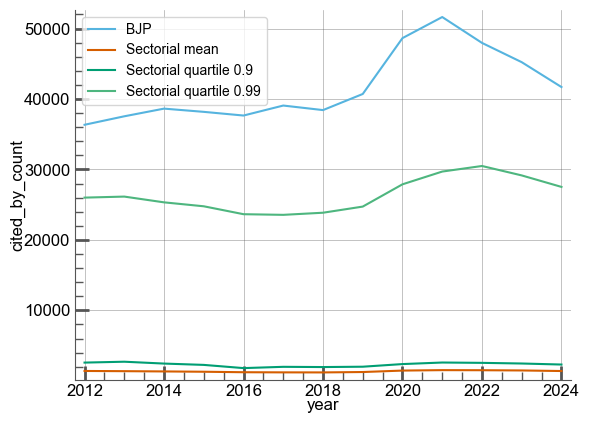

In [ ]:
with aquarel.load_theme("scientific"):
    sns.lineplot(data = df_source_and_co, x = "year", y = "cited_by_count", label = "BJP")
    sns.lineplot(data = df_source_and_co, x = "year", y = "cited_by_count_avg_concurrence", label = "Sectorial mean")
    sns.lineplot(data = df_source_and_co, x = "year", y = "cited_by_count_top_concurrence", label = f"Sectorial quartile {top}")
    sns.lineplot(data = df_source_and_co, x = "year", y = "cited_by_count_toptop_concurrence", label = f"Sectorial quartile {toptop}")
    plt.legend(loc = "upper left")
    plt.show()

## Analysis - Topic Share

In [ ]:
source_topic_share = source["topic_share"]
df_topic_share = pd.DataFrame(source_topic_share).sort_values(by = "value", ascending = False)

top5_topics_bjp = df_topic_share[["display_name", "value"]].head(n = 5)
top5_topics_bjp.columns = ["Topic", "Share (%)"]
top5_topics_bjp["Share (%)"] = top5_topics_bjp["Share (%)"] * 100
top5_topics_bjp.to_csv("data/sources/top5_topics_bjp.csv", index = False)

In [22]:
topic_share_concurrence = pd.DataFrame()
for index in df_concurrence.index:
    for j in df_concurrence.loc[index, "topic_share"]:
        topic_share_concurrence = pd.concat([topic_share_concurrence, pd.DataFrame([j])], ignore_index = True)

In [75]:
topic_share_concurrence_treated = (topic_share_concurrence[["display_name", "value"]].groupby(by = "display_name").mean()).sort_values(by = "value", ascending = False)

topic_share_concurrence_treated.reset_index(inplace = True)
top5_topics_concurrence = topic_share_concurrence_treated.loc[:,["display_name", "value"]].head(n = 5)
top5_topics_concurrence.columns = ["Topic", "Share (%)"]
top5_topics_concurrence["Share (%)"] = top5_topics_concurrence["Share (%)"] * 100
top5_topics_concurrence.to_csv("data/sources/top5_topics_concurrence.csv", index = False)

# Works

### Latest version

In [42]:
data = []

pager = alex.Works().filter(locations={"source": {"id": "s55107261"}}).paginate(per_page = 200, n_max = None)
for page in pager:
    for work in page:
        authors = []
        institutions = []
        countries = []
        for i in work.get("authorships"):
            authors.append((i.get("author")).get("id"))

            for j in i.get("institutions"):
                institutions.append([j.get("display_name"), j.get("id")])

            for j in i.get("countries"):
                countries.append(j)

        new = {
            "title": work.get("title"),
            "year": work.get("publication_year"),
            "cited_by_count": work.get("cited_by_count"),          
            "countries_distinct_count": work.get("countries_distinct_count"),
            "institutions_distinct_count": work.get("institutions_distinct_count"),
            "citation_normalized_percentile": work.get("citation_normalized_percentile"),
            "primary_topic": work.get("primary_topic"), 
            "keywords": work.get("keywords"), 
            "concepts": work.get("concepts"),
            "referenced_works_count": work.get("referenced_works_count"),
            "referenced_works": work.get("referenced_works"), 
            "abstract": work["abstract"],
            "abstract_inverted_index": work.get("abstract_inverted_index"),
            "journal":work.get("primary_location").get("source").get("display_name")
        }
        for i in range(1, len(authors) + 1):
            new[f"author_{i}"] = authors[i - 1]
        for i in range(1, len(institutions) + 1):
            new[f"institution_{i}"] = institutions[i - 1]
        for i in range(1, len(countries) + 1):
            new[f"country_{i}"] = countries[i - 1]
        for i in work.get("counts_by_year"):
            new[f"cited_by_count_{i.get("year")}"] = i.get("cited_by_count")
        if work.get("primary_topic") != None:
            new["primary_topic"] =  (work.get("primary_topic")).get("display_name"),
            new["primary_subfield"] =  ((work.get("primary_topic")).get("subfield")).get("display_name"),
            new["primary_field"] =  ((work.get("primary_topic")).get("field")).get("display_name"),
            new["primary_domain"] =  ((work.get("primary_topic")).get("domain")).get("display_name"),

        count = 1
        for i in work.get("keywords"):
            new[f"keyword_{count}"] = i.get("display_name")
            count += 1

        data.append(new)
data = pd.DataFrame(data)

In [43]:
data

,title,year,cited_by_count,countries_distinct_count,institutions_distinct_count,citation_normalized_percentile,primary_topic,keywords,concepts,referenced_works_count,...,institution_117,institution_118,institution_119,institution_120,institution_121,institution_122,institution_123,institution_124,institution_125,institution_126
0,Animal research: Reporting <i>in vivo</i> expe...,2010,3447,1,4,"{'value': 0.999709, 'is_in_top_1_percent': Tru...","(Animal testing and alternatives,)",[{'id': 'https://openalex.org/keywords/watson'...,"[{'id': 'https://openalex.org/C161191863', 'wi...",6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Principles of early drug discovery,2010,2454,1,2,"{'value': 0.756098, 'is_in_top_1_percent': Fal...","(Computational Drug Discovery Methods,)",[{'id': 'https://openalex.org/keywords/identif...,"[{'id': 'https://openalex.org/C74187038', 'wik...",25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Measuring reactive species and oxidative damag...,2004,2198,1,1,"{'value': 0.990741, 'is_in_top_1_percent': Tru...","(Antioxidant Activity and Oxidative Stress,)",[],"[{'id': 'https://openalex.org/C207001950', 'wi...",386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Guide to Receptors and Channels (GRAC), 5th ed...",2011,2072,1,3,"{'value': 0.999918, 'is_in_top_1_percent': Tru...","(Inflammatory mediators and NSAID effects,)",[],"[{'id': 'https://openalex.org/C170493617', 'wi...",2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Characterization of three inhibitors of endoth...,1990,1875,1,1,"{'value': 0.999876, 'is_in_top_1_percent': Tru...","(Nitric Oxide and Endothelin Effects,)",[{'id': 'https://openalex.org/keywords/omega-n...,"[{'id': 'https://openalex.org/C2908937200', 'w...",37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26346,None,1986,0,0,0,None,None,[],"[{'id': 'https://openalex.org/C41008148', 'wik...",0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26347,Transdermal Iontophoresis - Role of the Stratu...,1994,0,0,0,"{'value': 0.0, 'is_in_top_1_percent': False, '...","(Chemotherapy-related skin toxicity,)",[{'id': 'https://openalex.org/keywords/iontoph...,"[{'id': 'https://openalex.org/C183529106', 'wi...",0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26348,ORAL COMMUNICATIONS,1991,0,0,0,"{'value': 0.0, 'is_in_top_1_percent': False, '...","(Attention Deficit Hyperactivity Disorder,)",[],"[{'id': 'https://openalex.org/C71924100', 'wik...",266,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26349,Interleukin 1 and lipopolysaccharide effects o...,1989,0,0,0,"{'value': 0.0, 'is_in_top_1_percent': False, '...","(Inflammatory mediators and NSAID effects,)",[{'id': 'https://openalex.org/keywords/interle...,"[{'id': 'https://openalex.org/C2777956040', 'w...",0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data.to_csv("data/works/works_journals.csv", index = False)

## Old datasets (do not run)

#### Works with all the features


In [10]:
works_request = alex.Works().filter(locations={"source": {"id": "s55107261"}}).get()
works_request.meta

{'count': 26307,
 'db_response_time_ms': 95,
 'page': 1,
 'per_page': 25,
 'groups_count': None}

In [ ]:
data = []

pager = alex.Works().filter(locations={"source": {"id": "s55107261"}}).paginate(per_page = 200, n_max = None)
for page in pager:
    for work in page:
        authors = []
        institutions = []
        countries = []
        for i in work.get("authorships"):
            authors.append((i.get("author")).get("id"))

            for j in i.get("institutions"):
                institutions.append([j.get("display_name"), j.get("id")])

            for j in i.get("countries"):
                countries.append(j)

        nouveau = {
            "title": work.get("title"),
            "year": work.get("publication_year"),
            "cited_by_count": work.get("cited_by_count"),          
            "countries_distinct_count": work.get("countries_distinct_count"),
            "institutions_distinct_count": work.get("institutions_distinct_count"),
            "citation_normalized_percentile": work.get("citation_normalized_percentile"),
            "primary_topic": work.get("primary_topic"), 
            "keywords": work.get("keywords"), 
            "concepts": work.get("concepts"),
            "referenced_works_count": work.get("referenced_works_count"),
            "referenced_works": work.get("referenced_works"), 
        }
        for i in range(1, len(authors) + 1):
            nouveau[f"author_{i}"] = authors[i - 1]
        for i in range(1, len(institutions) + 1):
            nouveau[f"institution_{i}"] = institutions[i - 1]
        for i in range(1, len(countries) + 1):
            nouveau[f"country_{i}"] = countries[i - 1]
        for i in work.get("counts_by_year"):
            nouveau[f"cited_by_count_{i.get("year")}"] = i.get("cited_by_count")
        if work.get("primary_topic") != None:
            nouveau["primary_topic"] =  (work.get("primary_topic")).get("display_name"),
            nouveau["primary_subfield"] =  ((work.get("primary_topic")).get("subfield")).get("display_name"),
            nouveau["primary_field"] =  ((work.get("primary_topic")).get("field")).get("display_name"),
            nouveau["primary_domain"] =  ((work.get("primary_topic")).get("domain")).get("display_name"),

        compteur = 1
        for i in work.get("keywords"):
            nouveau[f"keyword_{compteur}"] = i.get("display_name")
            compteur += 1

        data.append(nouveau)
data = pd.DataFrame(data)

In [11]:
data.shape

(26307, 386)

In [12]:
data.head()

,title,year,cited_by_count,countries_distinct_count,institutions_distinct_count,citation_normalized_percentile,primary_topic,keywords,concepts,referenced_works_count,...,institution_117,institution_118,institution_119,institution_120,institution_121,institution_122,institution_123,institution_124,institution_125,institution_126
0,Animal research: Reporting <i>in vivo</i> expe...,2010,3423,1,4,"{'value': 0.99971, 'is_in_top_1_percent': True...","(Animal testing and alternatives,)",[{'id': 'https://openalex.org/keywords/watson'...,"[{'id': 'https://openalex.org/C161191863', 'wi...",6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Principles of early drug discovery,2010,2407,1,2,"{'value': 0.77439, 'is_in_top_1_percent': Fals...","(Computational Drug Discovery Methods,)",[{'id': 'https://openalex.org/keywords/identif...,"[{'id': 'https://openalex.org/C74187038', 'wik...",25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Measuring reactive species and oxidative damag...,2004,2194,1,1,"{'value': 0.990741, 'is_in_top_1_percent': Tru...","(Antioxidant Activity and Oxidative Stress,)",[],"[{'id': 'https://openalex.org/C207001950', 'wi...",386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Guide to Receptors and Channels (GRAC), 5th ed...",2011,2071,1,3,"{'value': 0.999918, 'is_in_top_1_percent': Tru...","(Inflammatory mediators and NSAID effects,)",[],"[{'id': 'https://openalex.org/C170493617', 'wi...",2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Characterization of three inhibitors of endoth...,1990,1873,1,1,"{'value': 0.999876, 'is_in_top_1_percent': Tru...","(Nitric Oxide and Endothelin Effects,)",[{'id': 'https://openalex.org/keywords/omega-n...,"[{'id': 'https://openalex.org/C2908937200', 'w...",37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
data.to_csv("data/works/works.csv", index = False) 

35 117 articles found on Web of Science -> 75% rate. WoS : 1975 (400) -> 2025 (144)

Request for WoS : https://www.webofscience.com/wos/woscc/summary/d3461001-9761-4b75-989a-a5a634e37681-01680e4ad4/relevance/1

### Works with authors

In [2]:
data = pd.DataFrame({
    "title": [],
    "year": [],
    "cited_by_count": [],
    "authorships":[],
    "countries_distinct_count": [],
    "institutions_distinct_count":[],
    "citation_normalized_percentile": [],
    "primary_topic": [],
    "keywords": [],
    "concepts": [],
    "referenced_works_count": [],
    "referenced_works": []
})

for i in range(1, 31):
    data[f"author_{i}"] = []

pager = alex.Works().filter(locations={"source": {"id": "s55107261"}}).paginate(per_page = 200, n_max = None)
for page in pager:
    for work in page:
        authors = []
        for i in work.get("authorships"):
            authors.append((i.get("author")).get("id"))

        nouveau = {
            "title": work.get("title"),
            "year": work.get("publication_year"),
            "cited_by_count": work.get("cited_by_count"),          
            "countries_distinct_count": work.get("countries_distinct_count"),
            "institutions_distinct_count": work.get("institutions_distinct_count"),
            "citation_normalized_percentile": work.get("citation_normalized_percentile"),
            "primary_topic": work.get("primary_topic"), # à remanier comme authorships
            "keywords": work.get("keywords"), # à remanier
            "concepts": work.get("concepts"), # à remanier
            "referenced_works_count": work.get("referenced_works_count"),
            "referenced_works": work.get("referenced_works"), # à remanier
        }
        for i in range(1, len(authors) + 1):
            nouveau[f"author_{i}"] = authors[i - 1]

        data = pd.concat([data, pd.DataFrame([nouveau])])

KeyboardInterrupt: 

In [ ]:
data.to_csv('data/works/works_labels_authors.csv', index = False)

### Works with authors, institutions and countries labels

In [3]:
data = []

pager = alex.Works().filter(locations={"source": {"id": "s55107261"}}).paginate(per_page = 200, n_max = None)
for page in pager:
    for work in page:
        authors = []
        institutions = []
        countries = []
        for i in work.get("authorships"):
            authors.append((i.get("author")).get("id"))

            for j in i.get("institutions"):
                institutions.append([j.get("display_name"), j.get("id")])

            for j in i.get("countries"):
                countries.append(j)

        nouveau = {
            "title": work.get("title"),
            "year": work.get("publication_year"),
            "cited_by_count": work.get("cited_by_count"),          
            "countries_distinct_count": work.get("countries_distinct_count"),
            "institutions_distinct_count": work.get("institutions_distinct_count"),
            "citation_normalized_percentile": work.get("citation_normalized_percentile"),
            "primary_topic": work.get("primary_topic"), 
            "keywords": work.get("keywords"), 
            "concepts": work.get("concepts"),
            "referenced_works_count": work.get("referenced_works_count"),
            "referenced_works": work.get("referenced_works"), 
        }
        for i in range(1, len(authors) + 1):
            nouveau[f"author_{i}"] = authors[i - 1]
        for i in range(1, len(institutions) + 1):
            nouveau[f"institution_{i}"] = institutions[i - 1]
        for i in range(1, len(countries) + 1):
            nouveau[f"country_{i}"] = countries[i - 1]
        #data = pd.concat([data, pd.DataFrame([nouveau])])
        data.append(nouveau)
data = pd.DataFrame(data)

In [4]:
data.head()

,title,year,cited_by_count,countries_distinct_count,institutions_distinct_count,citation_normalized_percentile,primary_topic,keywords,concepts,referenced_works_count,...,institution_117,institution_118,institution_119,institution_120,institution_121,institution_122,institution_123,institution_124,institution_125,institution_126
0,Animal research: Reporting <i>in vivo</i> expe...,2010,3423,1,4,"{'value': 0.99971, 'is_in_top_1_percent': True...","{'id': 'https://openalex.org/T12281', 'display...",[{'id': 'https://openalex.org/keywords/watson'...,"[{'id': 'https://openalex.org/C161191863', 'wi...",6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Principles of early drug discovery,2010,2407,1,2,"{'value': 0.77439, 'is_in_top_1_percent': Fals...","{'id': 'https://openalex.org/T10211', 'display...",[{'id': 'https://openalex.org/keywords/identif...,"[{'id': 'https://openalex.org/C74187038', 'wik...",25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Measuring reactive species and oxidative damag...,2004,2194,1,1,"{'value': 0.990741, 'is_in_top_1_percent': Tru...","{'id': 'https://openalex.org/T10445', 'display...",[],"[{'id': 'https://openalex.org/C207001950', 'wi...",386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Guide to Receptors and Channels (GRAC), 5th ed...",2011,2071,1,3,"{'value': 0.999918, 'is_in_top_1_percent': Tru...","{'id': 'https://openalex.org/T10678', 'display...",[],"[{'id': 'https://openalex.org/C170493617', 'wi...",2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Characterization of three inhibitors of endoth...,1990,1873,1,1,"{'value': 0.999876, 'is_in_top_1_percent': Tru...","{'id': 'https://openalex.org/T10155', 'display...",[{'id': 'https://openalex.org/keywords/omega-n...,"[{'id': 'https://openalex.org/C2908937200', 'w...",37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
data.to_csv('data/works/works_labels_authors_institutions_countries.csv', index = False)

### Works with funders

In [ ]:
data = []      

pager = alex.Works().filter(locations={"source": {"id": "s55107261"}}).paginate(per_page = 200, n_max = None)
for page in pager:
    for work in page:
        authors = []
        institutions = []
        countries = []
        for i in work.get("authorships"):
            authors.append((i.get("author")).get("id"))

            for j in i.get("institutions"):
                institutions.append([j.get("display_name"), j.get("id"), j.get("type")])

            for j in i.get("countries"):
                countries.append(j)

        nouveau = {
            "title": work.get("title"),
            "year": work.get("publication_year"),
            "cited_by_count": work.get("cited_by_count"),          
            "countries_distinct_count": work.get("countries_distinct_count"),
            "institutions_distinct_count": work.get("institutions_distinct_count"),
            "citation_normalized_percentile": work.get("citation_normalized_percentile"),
            "primary_topic": work.get("primary_topic"), # à remanier comme authorships
            "keywords": work.get("keywords"), # à remanier
            "concepts": work.get("concepts"), # à remanier
            "referenced_works_count": work.get("referenced_works_count"),
            "referenced_works": work.get("referenced_works"), # à remanier
        }
        for i in range(1, len(authors) + 1):
            nouveau[f"author_{i}"] = authors[i - 1]
        for i in range(1, len(institutions) + 1):
            nouveau[f"institution_{i}"] = institutions[i - 1]
        for i in range(1, len(countries) + 1):
            nouveau[f"country_{i}"] = countries[i - 1]
        data.append(nouveau)
data = pd.DataFrame(data)

In [6]:
data.to_csv('data/works/works_funders.csv', index = False)

### Works with authors and institutions statistics

In [2]:
data = []
pager = alex.Works().filter(locations={"source": {"id": "s55107261"}}).paginate(per_page = 200, n_max = None)
for page in pager:
    for work in page:
        authors = []
        institutions = []
        countries = []
        for i in work.get("authorships"):
            authors.append((i.get("author")).get("id"))

            for j in i.get("institutions"):
                institutions.append([j.get("display_name"), j.get("id")])

            for j in i.get("countries"):
                countries.append(j)

        nouveau = {
            "title": work.get("title"),
            "year": work.get("publication_year"),
            "cited_by_count": work.get("cited_by_count"),          
            "countries_distinct_count": work.get("countries_distinct_count"),
            "institutions_distinct_count": work.get("institutions_distinct_count"),
            "citation_normalized_percentile": work.get("citation_normalized_percentile"),
            "primary_topic": work.get("primary_topic"), # à remanier comme authorships
            "keywords": work.get("keywords"), # à remanier
            "concepts": work.get("concepts"), # à remanier
            "referenced_works_count": work.get("referenced_works_count"),
            "referenced_works": work.get("referenced_works"), # à remanier
        }
        for i in range(1, len(authors) + 1):
            nouveau[f"author_{i}"] = authors[i - 1]
        for i in range(1, len(institutions) + 1):
            nouveau[f"institution_{i}"] = institutions[i - 1]
        for i in range(1, len(countries) + 1):
            nouveau[f"country_{i}"] = countries[i - 1]
        #data = pd.concat([data, pd.DataFrame([nouveau])])
        data.append(nouveau)
data = pd.DataFrame(data)

In [4]:
data.head()

,title,year,cited_by_count,countries_distinct_count,institutions_distinct_count,citation_normalized_percentile,primary_topic,keywords,concepts,referenced_works_count,...,institution_117,institution_118,institution_119,institution_120,institution_121,institution_122,institution_123,institution_124,institution_125,institution_126
0,Animal research: Reporting <i>in vivo</i> expe...,2010,3423,1,4,"{'value': 0.99971, 'is_in_top_1_percent': True...","{'id': 'https://openalex.org/T12281', 'display...",[{'id': 'https://openalex.org/keywords/watson'...,"[{'id': 'https://openalex.org/C161191863', 'wi...",6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Principles of early drug discovery,2010,2407,1,2,"{'value': 0.775758, 'is_in_top_1_percent': Fal...","{'id': 'https://openalex.org/T10211', 'display...",[{'id': 'https://openalex.org/keywords/identif...,"[{'id': 'https://openalex.org/C74187038', 'wik...",25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Measuring reactive species and oxidative damag...,2004,2194,1,1,"{'value': 0.990741, 'is_in_top_1_percent': Tru...","{'id': 'https://openalex.org/T10445', 'display...",[],"[{'id': 'https://openalex.org/C207001950', 'wi...",386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Guide to Receptors and Channels (GRAC), 5th ed...",2011,2071,1,3,"{'value': 0.999918, 'is_in_top_1_percent': Tru...","{'id': 'https://openalex.org/T10678', 'display...",[],"[{'id': 'https://openalex.org/C170493617', 'wi...",2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Characterization of three inhibitors of endoth...,1990,1873,1,1,"{'value': 0.999876, 'is_in_top_1_percent': Tru...","{'id': 'https://openalex.org/T10155', 'display...",[{'id': 'https://openalex.org/keywords/omega-n...,"[{'id': 'https://openalex.org/C2908937200', 'w...",37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
test = (alex.Authors()["https://openalex.org/A5004753412"])["summary_stats"]["h_index"]
print(type(test))

<class 'int'>


In [57]:
authors = alex.Authors()

book = []

# pages
for i in range(1, 517550):
    book.append(authors.get(page = i, per_page = 200))

# Save the pages
for i in range(1, 517550):
    with open(f"authors_{i}.json", "w") as f:
        json.dump(book[i-1], f, indent = 4)


HTTPError: 403 Client Error: FORBIDDEN for url: https://api.openalex.org/authors?per-page=200&page=51

In [55]:
103511364/200

517556.82

In [50]:
for index, row in data.iterrows():
    i = 1 #

    while pd.notna(row[f"author_{i}"]):
        data[f"hindex_author_{i}"] = (
            alex.Authors()
            [row[f"author_{i}"]]
            ["summary_stats"]
            ["h_index"]
        )
        if index%100 == 0:
            print(f"progression : {(index / data.shape[0]) * 100} %")

        i += 1

progression : 0.0 %
progression : 0.0 %
progression : 0.0 %
progression : 0.0 %
progression : 0.0 %


KeyboardInterrupt: 

In [11]:
# succès en fonction de l'année du premier travail (= de l'âge de l'auteur)

### Works with counts by year

In [ ]:
data = pd.DataFrame({
    "title": [],
    "year": [],
    "cited_by_count": [],
    "authorships":[],
    "countries_distinct_count": [],
    "institutions_distinct_count":[],
    "citation_normalized_percentile": [],
    "primary_topic": [],
    "keywords": [],
    "concepts": [],
    "referenced_works_count": [],
    "referenced_works": [],
    "counts_by_year": []
})

pager = alex.Works().filter(locations={"source": {"id": "s55107261"}}).paginate(per_page = 200, n_max = None)
for page in pager:
    # counts_by_year = []
    for work in page:
        # for i in work.get("counts_by_year"):
        #     counts_by_year.append({
        #         "year": i.get("year"),
        #         "cited_by_count" : i.get("cited_by_count")
        #         })

        nouveau = {
            "title": work.get("title"),
            "year": work.get("publication_year"),
            "cited_by_count": work.get("cited_by_count"),          
            "countries_distinct_count": work.get("countries_distinct_count"),
            "institutions_distinct_count": work.get("institutions_distinct_count"),
            "primary_topic": work.get("primary_topic"), # à remanier comme authorships
            "keywords": work.get("keywords"), # à remanier
            "topics": work.get("topics"), # à remanier
            "referenced_works_count": work.get("referenced_works_count"),
        }
        for i in work.get("counts_by_year"):
            nouveau[f"cited_by_count_{i.get("year")}"] = i.get("cited_by_count")
        data = pd.concat([data, pd.DataFrame([nouveau])])

Faster version:

In [5]:
data = []

pager = alex.Works().filter(locations={"source": {"id": "s55107261"}}).paginate(per_page = 200, n_max = None)
for page in pager:
    # counts_by_year = []
    for work in page:
        # for i in work.get("counts_by_year"):
        #     counts_by_year.append({
        #         "year": i.get("year"),
        #         "cited_by_count" : i.get("cited_by_count")
        #         })

        nouveau = {
            "title": work.get("title"),
            "year": work.get("publication_year"),
            "cited_by_count": work.get("cited_by_count"),          
            "countries_distinct_count": work.get("countries_distinct_count"),
            "institutions_distinct_count": work.get("institutions_distinct_count"),
            "primary_topic": work.get("primary_topic"), # à remanier comme authorships
            "keywords": work.get("keywords"), # à remanier
            "topics": work.get("topics"), # à remanier
            "referenced_works_count": work.get("referenced_works_count"),
        }
        for i in work.get("counts_by_year"):
            nouveau[f"cited_by_count_{i.get("year")}"] = i.get("cited_by_count")
        data.append(nouveau)
data = pd.DataFrame(data)

In [6]:
data.to_csv("data/works/works/works_counts_by_year_topics.csv")


### Works with primary topics

In [7]:
data = []

pager = alex.Works().filter(locations={"source": {"id": "s55107261"}}).paginate(per_page = 200, n_max = None)
for page in pager:
    for work in page:
        nouveau = {
            "title": work.get("title"),
            "year": work.get("publication_year"),
            "cited_by_count": work.get("cited_by_count"),
            "countries_distinct_count": work.get("countries_distinct_count"),
            "institutions_distinct_count": work.get("institutions_distinct_count"),
            "referenced_works_count": work.get("referenced_works_count")
        }
        
        if work.get("primary_topic") != None:
            nouveau["primary_topic"] =  (work.get("primary_topic")).get("display_name"),
            nouveau["primary_subfield"] =  ((work.get("primary_topic")).get("subfield")).get("display_name"),
            nouveau["primary_field"] =  ((work.get("primary_topic")).get("field")).get("display_name"),
            nouveau["primary_domain"] =  ((work.get("primary_topic")).get("domain")).get("display_name"),

        compteur = 1
        for i in work.get("keywords"):
            nouveau[f"keyword_{compteur}"] = i.get("display_name")
            compteur += 1
        data.append(nouveau)
data = pd.DataFrame(data)

In [10]:
data.to_csv("./data/works/works/works_topics_keywords.csv", index = None)

# Works (all pharmacology)

In [7]:
top_50 = df_concurrence[["display_name", "impact", "cited_by_count", "host_organization", "works_count", "id"]].sort_values(by = "impact", ascending = False).reset_index()[:50]

In [8]:
works_count = 0
for source in top_50["id"]:
    result = alex.Works().filter(locations={"source": {"id": source}}).get()
    works_count += result.meta["count"]

In [9]:
data = []
progress = 0

for source in top_50["id"]:
    pager = alex.Works().filter(locations={"source": {"id": source}}).paginate(per_page = 200, n_max = None)
    for page in pager:
        for work in page:
            authors = []
            institutions = []
            countries = []
            for i in work.get("authorships"):
                authors.append((i.get("author")).get("id"))

                for j in i.get("institutions"):
                    institutions.append([j.get("display_name"), j.get("id")])

                for j in i.get("countries"):
                    countries.append(j)

            new = {
                "title": work.get("title"),
                "year": work.get("publication_year"),
                "cited_by_count": work.get("cited_by_count"),          
                "countries_distinct_count": work.get("countries_distinct_count"),
                "institutions_distinct_count": work.get("institutions_distinct_count"),
                "citation_normalized_percentile": work.get("citation_normalized_percentile"),
                "primary_topic": work.get("primary_topic"), 
                "keywords": work.get("keywords"), 
                "concepts": work.get("concepts"),
                "referenced_works_count": work.get("referenced_works_count"),
                "referenced_works": work.get("referenced_works"), 
                "abstract": work["abstract"],
                "abstract_inverted_index": work.get("abstract_inverted_index"),
                "journal":work.get("primary_location").get("source").get("display_name")

            }
            for i in range(1, len(authors) + 1):
                new[f"author_{i}"] = authors[i - 1]
            for i in range(1, len(institutions) + 1):
                new[f"institution_{i}"] = institutions[i - 1]
            for i in range(1, len(countries) + 1):
                new[f"country_{i}"] = countries[i - 1]
            for i in work.get("counts_by_year"):
                new[f"cited_by_count_{i.get("year")}"] = i.get("cited_by_count")
            if work.get("primary_topic") != None:
                new["primary_topic"] =  (work.get("primary_topic")).get("display_name"),
                new["primary_subfield"] =  ((work.get("primary_topic")).get("subfield")).get("display_name"),
                new["primary_field"] =  ((work.get("primary_topic")).get("field")).get("display_name"),
                new["primary_domain"] =  ((work.get("primary_topic")).get("domain")).get("display_name"),

            count = 1
            for i in work.get("keywords"):
                new[f"keyword_{count}"] = i.get("display_name")
                count += 1
            
            progress +=1
            if progress%1000 == 0:
                print(progress/works_count*100)
                clear_output(wait=True)

            data.append(new)

99.72266477842686


In [12]:
data_chunks = []
for i in range(0, len(data), 10_000):
    data_chunks.append(data[i:i + 10_000])

In [13]:
data = pd.DataFrame()
for i in range(len(data_chunks)):
    data_chunks[i] = pd.DataFrame(data_chunks[i])
    

In [14]:
df = pd.concat(data_chunks)

In [15]:
df.to_csv("data_pharmacology/data_journals.csv")